# GAT — отчёт по результатам

**Горизонт:** 24 часа
**Конфигурация:** D — обе идеи (1+2): adaptive embeddings + adaptive adjacency (запуск без флагов энкодера)  

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Параметры отчёта
HORIZON = 24
CONFIG_LABEL = "D — обе идеи (embeddings + adjacency)"

# Путь к сохранённым результатам обучения (Kaggle), с локальным фолбэком
CANDIDATES = [
    "/kaggle/input/notebooks/raviol/gat-leaning-claude/eda_output",
    "/kaggle/working/eda_output",
    "eda_output",
]
DATA_DIR = next((p for p in CANDIDATES if os.path.isdir(p)), CANDIDATES[0])
print("Читаю результаты из:", DATA_DIR)
print("Файлы:", [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')] if os.path.isdir(DATA_DIR) else "(папка не найдена)")

Читаю результаты из: eda_output
Файлы: ['final_clusters.csv', 'gat_summary_24h.csv', 'gat_synth_validation_24h.csv', 'gat_results_24h.csv', 'gat_history_24h.csv']


In [2]:
def load_csv(name):
    path = os.path.join(DATA_DIR, name)
    return pd.read_csv(path) if os.path.exists(path) else None

summary = load_csv(f"gat_summary_{HORIZON}h.csv")
results = load_csv(f"gat_results_{HORIZON}h.csv")
history = load_csv(f"gat_history_{HORIZON}h.csv")

for name, df in [("summary", summary), ("results", results), ("history", history)]:
    print(f"{name:8s} -> {None if df is None else df.shape}")

summary  -> (1, 10)
results  -> (4474, 15)
history  -> (33, 6)


## 1. Итоговые метрики

In [3]:
if summary is not None:
    display(summary)
else:
    print("Нет gat_summary — считаю сводку из results.")
    if results is not None:
        agg = results.groupby(["horizon", "train_mode", "model"]).agg(
            MAE=("MAE", "mean"), RMSE=("RMSE", "mean"), MAPE=("MAPE", "mean"),
            SMAPE=("SMAPE", "mean"), WAPE=("WAPE", "mean"),
            n_objects=("object_id", "nunique"), n_rows=("MAE", "count"),
        ).round(4).reset_index()
        display(agg)

,horizon,train_mode,model,MAE,RMSE,MAPE,SMAPE,WAPE,n_objects,n_rows
0,24,real_plus_synth,GAT,43.6464,58.4028,23.8155,24.5804,18.8233,1500,4474


In [4]:
# Карточка с ключевыми метриками (среднее по объектам/фолдам)
if results is not None:
    print(f"=== {CONFIG_LABEL} · h={HORIZON} ===")
    for m in ["MAE", "RMSE", "MAPE", "SMAPE", "WAPE"]:
        if m in results:
            print(f"  {m:6s} = {results[m].mean():.4f}")
    print(f"  объектов: {results['object_id'].nunique()} · фолдов: {results['fold'].nunique()} · строк: {len(results)}")

=== D — обе идеи (embeddings + adjacency) · h=24 ===
  MAE    = 43.6464
  RMSE   = 58.4028
  MAPE   = 23.8155
  SMAPE  = 24.5804
  WAPE   = 18.8233
  объектов: 1500 · фолдов: 3 · строк: 4474


## 1b. Метрики по «зрелым» (последним) фолдам

Поздние фолды обучены на наибольшей истории → ближе к реальному использованию. Усредняем по последним двум фолдам (`fold >= max_fold − 1`) и группируем по `train_mode`

In [5]:
# Метрики по "зрелым" фолдам (последние 2: max_fold и max_fold-1).
# Поздние фолды обучены на бОльшей истории → ближе к боевому прогнозу.
def get_mature_metrics(df, horizon_name):
    max_fold = df["fold"].max()
    mature_df = df[df["fold"] >= max_fold - 1]          # последние 2 фолда
    stats = mature_df.groupby("train_mode").agg(
        MAE=("MAE", "mean"),
        SMAPE=("SMAPE", "mean"),
        WAPE=("WAPE", "mean"),
    ).round(2)
    stats["horizon"] = horizon_name
    return stats.reset_index()

frames = []
for h in [1, 24]:
    path = os.path.join(DATA_DIR, f"gat_results_{h}h.csv")
    if os.path.exists(path):
        frames.append(get_mature_metrics(pd.read_csv(path), f"{h}h"))

if frames:
    final_report = pd.concat(frames)[["horizon", "train_mode", "MAE", "SMAPE", "WAPE"]]
    display(final_report)
else:
    print("Нет gat_results_*.csv в", DATA_DIR)

,horizon,train_mode,MAE,SMAPE,WAPE
0,24h,real_plus_synth,39.42,26.08,20.61


## 2. Кривая обучения (loss по эпохам, по фолдам)

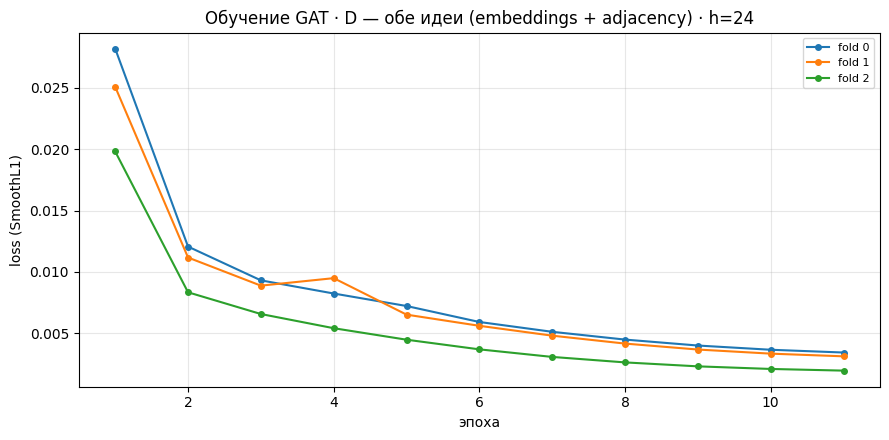

In [6]:
if history is not None and len(history):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    group_cols = [c for c in ["fold", "phase"] if c in history.columns]
    if group_cols:
        for key, g in history.groupby(group_cols):
            label = key if isinstance(key, str) else " · ".join(str(k) for k in np.atleast_1d(key))
            ax.plot(g["epoch"], g["loss"], marker="o", ms=4, label=f"fold {label}")
        ax.legend(fontsize=8)
    else:
        ax.plot(history["epoch"], history["loss"], marker="o", ms=4)
    ax.set_xlabel("эпоха"); ax.set_ylabel("loss (SmoothL1)")
    ax.set_title(f"Обучение GAT · {CONFIG_LABEL} · h={HORIZON}")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Нет истории обучения.")

## 3. Метрики по фолдам
Видно, какой фолд труднее (стабильность прогноза во времени).

,MAE,RMSE,MAPE,SMAPE,WAPE
fold,,,,,
0,52.135,70.563,17.508,21.577,15.400
1,52.369,69.931,34.292,30.208,24.657
2,26.585,34.919,19.683,21.979,16.564


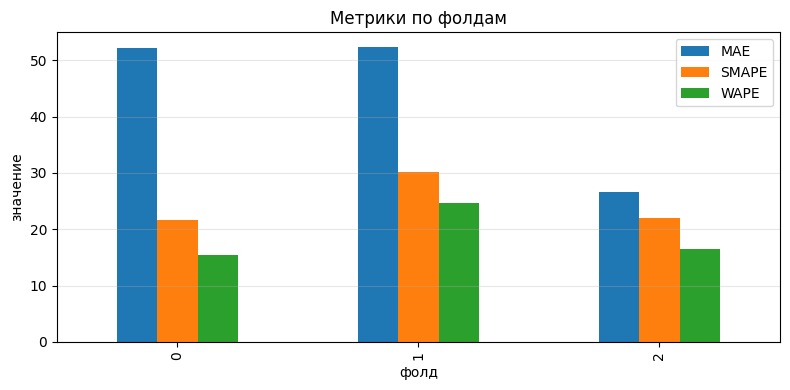

In [7]:
if results is not None:
    by_fold = results.groupby("fold")[["MAE", "RMSE", "MAPE", "SMAPE", "WAPE"]].mean().round(3)
    display(by_fold)
    fig, ax = plt.subplots(figsize=(8, 4))
    by_fold[["MAE", "SMAPE", "WAPE"]].plot(kind="bar", ax=ax)
    ax.set_xlabel("фолд"); ax.set_ylabel("значение")
    ax.set_title("Метрики по фолдам"); ax.grid(alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()

## 4. Распределение ошибки по объектам
Среднее vs медиана показывают, тянут ли хвост отдельные тяжёлые объекты.

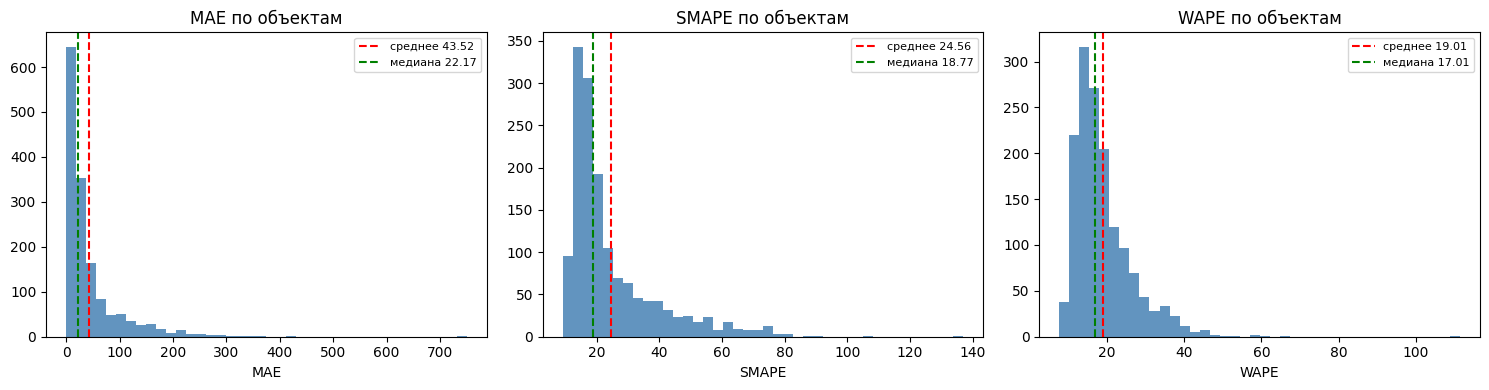

In [8]:
if results is not None:
    per_obj = results.groupby("object_id")[["MAE", "SMAPE", "WAPE", "y_mean"]].mean()
    metrics = ["MAE", "SMAPE", "WAPE"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, m in zip(axes, metrics):
        vals = per_obj[m].dropna()
        ax.hist(vals, bins=40, color="steelblue", alpha=0.85)
        ax.axvline(vals.mean(), color="red", ls="--", label=f"среднее {vals.mean():.2f}")
        ax.axvline(vals.median(), color="green", ls="--", label=f"медиана {vals.median():.2f}")
        ax.set_title(f"{m} по объектам"); ax.set_xlabel(m); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## 5. Ошибка vs объём объекта
MAE растёт с объёмом (крупные станции → большие абсолютные ошибки), SMAPE обычно наоборот.

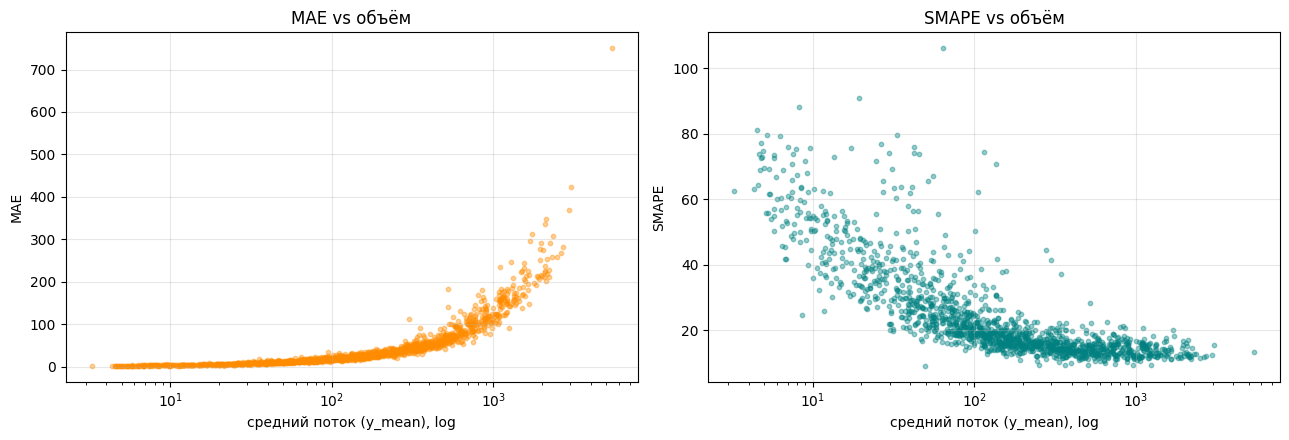

In [9]:
if results is not None and "y_mean" in results.columns:
    agg = results.groupby("object_id").agg(MAE=("MAE", "mean"), SMAPE=("SMAPE", "mean"),
                                           y_mean=("y_mean", "mean"))
    agg = agg[agg["y_mean"] > 0]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(agg["y_mean"], agg["MAE"], s=10, alpha=0.4, color="darkorange")
    axes[0].set_xscale("log"); axes[0].set_xlabel("средний поток (y_mean), log"); axes[0].set_ylabel("MAE")
    axes[0].set_title("MAE vs объём"); axes[0].grid(alpha=0.3)
    axes[1].scatter(agg["y_mean"], agg["SMAPE"], s=10, alpha=0.4, color="teal")
    axes[1].set_xscale("log"); axes[1].set_xlabel("средний поток (y_mean), log"); axes[1].set_ylabel("SMAPE")
    axes[1].set_title("SMAPE vs объём"); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 6. Топ объектов по ошибке

In [10]:
if results is not None:
    per_obj = results.groupby("object_id")[["MAE", "SMAPE", "WAPE", "y_mean"]].mean().round(2)
    print("Худшие 10 объектов по MAE:")
    display(per_obj.sort_values("MAE", ascending=False).head(10))
    print("Лучшие 10 объектов по MAE:")
    display(per_obj.sort_values("MAE").head(10))

Худшие 10 объектов по MAE:


,MAE,SMAPE,WAPE,y_mean
object_id,,,,
RT_7201,750.15,13.38,13.65,5396.50
ST_196,422.91,15.61,14.55,3038.11
ST_305,369.91,12.37,11.88,2945.19
ST_1783,348.83,17.07,16.78,2119.46
ST_1788,335.57,15.14,16.13,2075.94
ST_199,312.52,18.29,19.09,1732.39
ST_216,308.05,12.84,12.79,2354.76
ST_338,296.25,20.03,18.07,1694.24
ST_257,291.91,14.59,12.91,2239.72


Лучшие 10 объектов по MAE:


,MAE,SMAPE,WAPE,y_mean
object_id,,,,
RT_834,0.03,66.67,NaN,0.00
RT_2090,0.04,137.04,NaN,0.00
RT_3914,1.13,62.42,28.73,3.26
RT_816,1.55,63.88,16.48,8.48
RT_7315,1.57,54.04,24.03,5.52
RT_2023,1.63,63.22,37.06,4.33
ST_2000635,1.75,55.84,24.83,5.13
ST_2001087,1.77,72.67,25.89,4.76
RT_7392,1.81,45.63,29.08,6.41


## Вывод — D (обе идеи 1+2), h=24 — по последним 2 фолдам

- **Зрелые метрики (последние 2 фолда): MAE 39.42 · SMAPE 26.08 · WAPE 20.61** — **лучший результат среди всех методов по всем трём метрикам.**
- Против TFT (46.50 / 34.08 / 26.90): MAE **−15%**, SMAPE **−23%**, WAPE **−23%** — на длинном горизонте D впервые обгоняет TFT по всем метрикам.
- Резкий контраст с одиночными идеями: B — только embeddings 76.74, C — только adjacency 72.63. **Только пара 1+2 регуляризует node-эмбеддинги графовой структурой** и снимает переобучение на трудном фолде (по фолдам: 52 / 52 / 27; зрелый срез = последние два).

**Итог:** на h=24 синергия идей даёт качественный скачок — D бьёт TFT и обе одиночные идеи. Дальнейший рычаг проекта — `D + TimesNet` (чемпион).